In [45]:
#!pip install numpy scikit-learn matplotlib

In [46]:
import numpy as np
import sklearn
import matplotlib

from sklearn.datasets import load_digits

In [47]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [48]:
data = digits["data"]
images = digits["images"]
target = digits["target"]
target_names = digits["target_names"]

data[0].shape, images[0].shape, target[0], target_names[0]

((64,), (8, 8), np.int64(0), np.int64(0))

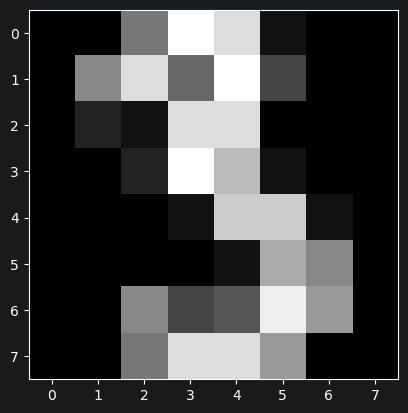

In [49]:
import numpy as np
import matplotlib . pyplot as plt
img = images[target == 3][0]
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [50]:
filte = (target % 3 == 0) * (target % 2 != 0)

filtered_data = data[filte]
filtered_target = target[filte]

filtered_target[filtered_target==3] = -1
filtered_target[filtered_target==9] = 1

filtered_target

array([-1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
        1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,
        1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,
        1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,
        1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,
        1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,
        1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,
        1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,
        1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
       -1,  1,  1, -1, -1

In [51]:
from sklearn import model_selection

X_all = filtered_data #/ 255
y_all = filtered_target

X_train, X_test, y_train, y_test =\
    model_selection.train_test_split(X_all, y_all,
        test_size = 0.4 , random_state = 0)

(8, 8)


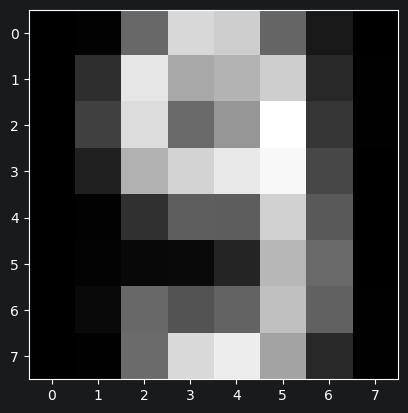

In [52]:
img = X_train[y_train == 1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


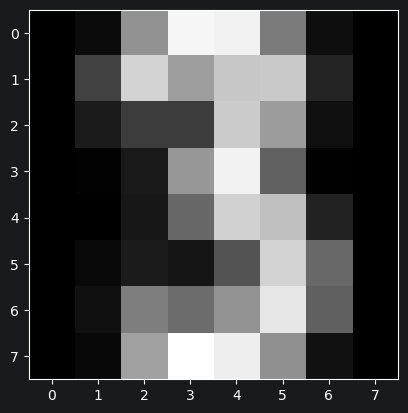

In [53]:
import numpy as np
import matplotlib . pyplot as plt
img = X_train[y_train == -1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


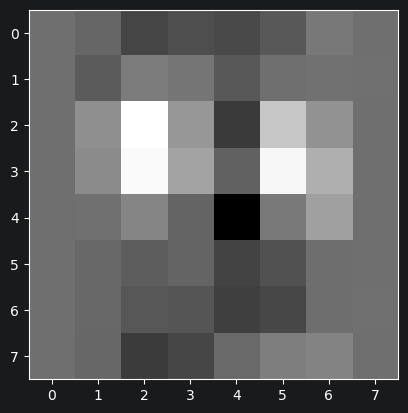

In [54]:
import numpy as np
import matplotlib . pyplot as plt
img = (X_train[y_train == 1].mean(axis=0) - X_train[y_train == -1].mean(axis=0)).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [55]:
def handcrafted_conv(x):
    
    conv_matrix = np.array([[0,0,0,0], [0,0,0,0], [0.5, -1, 1, -0.5], [0.5, -1, 1, -0.5]])
    
    
    print((x * conv_matrix).shape)
    
    val = (x[:] * conv_matrix).sum(axis=2).sum(axis=1)
    
    return val


def features2d(x: np.array):
    
    f_1 = 0
    
    f_1 = x[:, 2*8+2] + x[:, 3*8+2] - 15# * 2 #- x[:, 2*8+1] * 2
    #for i in range(1):
     #   sub_matrix = np.array([x[:, 4*i:4*i+4], x[:, 4*i+8:4*i+12], x[:, 4*i+16:4*i+20], x[:, 4*i+24:4*i+28]]).reshape((x.shape[0], 4, 4))
      #  f_1 += handcrafted_conv(sub_matrix)
    
    #print(f_1)
    
    f_2 = 0
    #for i in range(2):
     #   sub_matrix = np.array([x[:, 4*i+32:4*i+4+32], x[:, 4*i+8+32:4*i+12+32], x[:, 4*i+16+32:4*i+20+32], x[:, 4*i+24+32:4*i+28+32]]).reshape((x.shape[0], 4, 4))
      #  f_2 += handcrafted_conv(sub_matrix)
    
    #f_2 = (x[:, 3*8+2]*3 - x[:, 3*8+3] - x[:, 7*8+2] ** 4 / 1000 - x[:, 7*8+1] ** 4 / 1000 + x[:, 3*8+5] ** 3 / 8 + x[:, 3*8+6] * 100 - x[:, 2*8+6] * 100) / 20
    #f_2 = (-x[:, 7*8+2] ** 10  + x[:, 3*8+5] ** 10) / 100000000000 +( x[:, 3*8+7] ** 4 - x[:, 7*8+1] ** 4) / 10000
    
    f_2 = x[:, 2*8+5] *0.5 + x[:, 3*8+5] - 15
    
    #print(f_2)
    
        
    return f_1, f_2

In [56]:

def features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2 

    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

        
    return f_1, f_2

In [57]:
X_train[:4]

array([[ 0.,  0.,  0.,  1., 12., 16., 14.,  0.,  0.,  0.,  3., 14., 13.,
        15., 13.,  0.,  0.,  4., 16., 15., 13., 16.,  4.,  0.,  0.,  3.,
        16., 16., 16., 16.,  3.,  0.,  0.,  0.,  7.,  7., 14., 14.,  0.,
         0.,  0.,  0.,  0.,  0., 12., 11.,  0.,  0.,  0.,  0.,  0.,  0.,
        13., 10.,  0.,  0.,  0.,  0.,  0.,  0., 13., 12.,  0.,  0.],
       [ 0.,  0.,  9., 16., 14.,  6.,  0.,  0.,  0.,  6., 16.,  5., 10.,
        16.,  0.,  0.,  0.,  2., 15.,  7., 10., 16.,  3.,  0.,  0.,  0.,
         4.,  8., 12., 16.,  4.,  0.,  0.,  0.,  0.,  0.,  0., 16.,  7.,
         0.,  0.,  0.,  0.,  0.,  1., 16.,  8.,  0.,  0.,  0.,  3.,  0.,
         8., 16.,  1.,  0.,  0.,  0., 10., 16., 13.,  4.,  0.,  0.],
       [ 0.,  0.,  8., 14., 12.,  3.,  0.,  0.,  0.,  6., 16.,  6., 14.,
        14.,  0.,  0.,  0.,  6., 13.,  0.,  8., 14.,  0.,  0.,  0.,  2.,
        14., 14., 14., 16.,  3.,  0.,  0.,  0.,  2.,  4.,  6., 16.,  5.,
         0.,  0.,  0.,  0.,  0.,  0., 16.,  5.,  0.,  0.,  

In [58]:
x = X_train

print(x.shape)


features = features2d(x)

(217, 64)


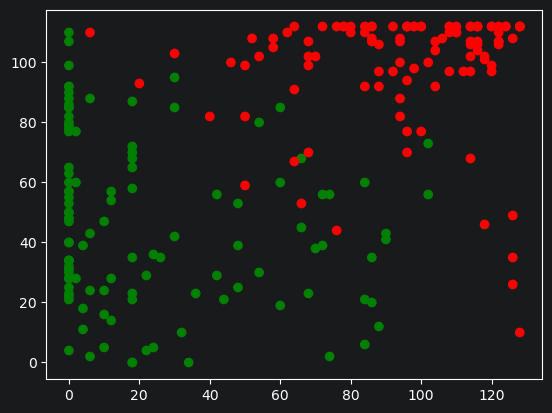

In [59]:
#print(features)

features = features2d(x)

color_dict = {-1: "green", 1: "red"} # Where green is 3s and red is 9s
colors = [color_dict[y] for y in y_train]

matplotlib.pyplot.scatter(features[0], features[1], c=colors)

In [60]:

def nearest_mean(training_features, training_labels, test_features):
    
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()
            
    #predicted_labels = np.array([1 if abs(x_9_mean**2 + y_9_mean**2 - test_features[0][i]**2 - test_features[1][i]**2) < abs(x_3_mean**2 + y_3_mean**2 - test_features[0][i]**2 - test_features[1][i]**2) else -1 for i in range(len(test_features[0]))])
    predicted_labels = np.array([1 if abs((x_9_mean - test_features[0][i])**2 + (y_9_mean - test_features[1][i])**2) < (x_3_mean - test_features[0][i])**2 + (y_3_mean - test_features[1][i])**2 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

def descision_function(training_features, training_labels, test_features):
    
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()
    
    beta1 = 1/210
    beta2 = 1/220
    b1 = -0.5
    b2 = -0.5
            
    predicted_labels = np.array([1 if (test_features[0][i]*beta1 + b1) + (test_features[1][i]*beta2 + b2) > 0 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

In [61]:
training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1


predicted_labels = nearest_mean(training_features, training_labels, test_features)

In [62]:
predicted_labels

array([ 1,  1,  1, -1, -1,  1,  1,  1, -1, -1, -1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,
       -1,  1, -1, -1,  1, -1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1,
       -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1, -1,
       -1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,
        1,  1,  1, -1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1, -1,  1, -1, -1, -1,  1,  1])

In [63]:
#F P +#F N
#    N

def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])
    
    
    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N
    

In [64]:
true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)

In [65]:
errors

(np.int64(70),
 np.int64(65),
 np.int64(7),
 np.int64(4),
 146,
 np.float64(0.07534246575342465),
 np.float64(0.9246575342465754))

In [66]:


def features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 4 + x[:, 3*8+2] * 8#- 15# * 2 #- x[:, 2*8+1] * 2

    f_2 = x[:, 2*8+5] * 5 + x[:, 3*8+5] * 9#- 15

        
    return f_1, f_2


training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1


predicted_labels = nearest_mean(training_features, training_labels, test_features)
predicted_labels2 = descision_function(training_features, training_labels, test_features)

true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)
errors2 = calculate_errors(predicted_labels2, true_labels)

errors[-1], errors[-2], errors2[-1], errors2[-2]

(np.float64(0.9794520547945206),
 np.float64(0.02054794520547945),
 np.float64(0.9794520547945206),
 np.float64(0.02054794520547945))

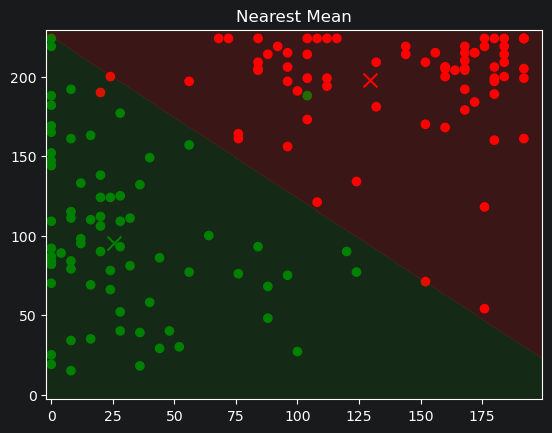

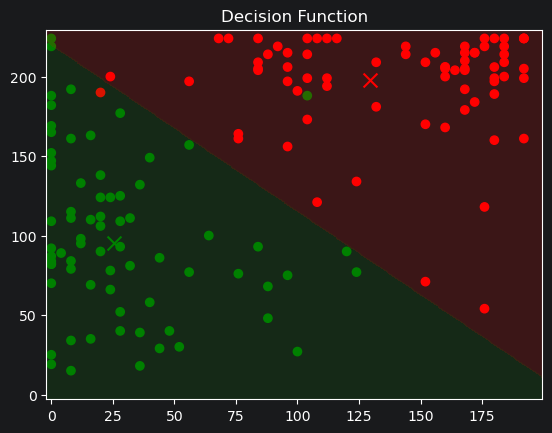

In [67]:
import matplotlib.pyplot as plt
import numpy as np


#fig, ax = plt.subplots()


color_dict = {-1: "green", 1: "red"}
colors = [color_dict[y] for y in true_labels]

#ax.scatter(test_features[0], test_features[1], c=colors)

x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()

xx, yy = np.meshgrid(np.arange(-2, 200, 0.5), np.arange(-3, 230, 0.5))
grid = (xx.ravel(), yy.ravel())

for func, name in [(nearest_mean, "Nearest Mean"), (descision_function, "Decision Function")]:
    fig, ax = plt.subplots()
    colors = [color_dict[y] for y in true_labels]
    ax.scatter(test_features[0], test_features[1], c=colors)
    ax.scatter(x_9_mean, y_9_mean, c="red", marker="x", s=100)
    ax.scatter(x_3_mean, y_3_mean, c="green", marker="x", s=100)

    Z = func(training_features, training_labels, grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["green", "red"], alpha=0.15)
    ax.set_title(name)
    plt.show()


# SVM

In [68]:
# For Graphing Later
losses = []
training_errors = []

def fit_svm(training_features, training_labels):
    if type(training_features) == tuple:
        training_features = np.array(training_features).reshape(training_labels.shape[0], -1)
        
    
    n = training_features.shape[0]

    beta = np.random.normal(size=(training_features.shape[1]))
    b = 0#np.random.normal(size=(training_features.shape[1]))
    
    lamb = 1
    tau = .1
    
    #print(training_labels.shape, training_features.shape, beta.shape)
    
    #print((training_labels * (training_features @ beta + b)).shape)
    
    loss_old = 100000
    count = 0
    
    for x in range(10000):
        
        
        mask = (1 - training_labels * (training_features @ beta + b)) > 0


        beta = beta - tau * lamb/n * (-training_labels[mask] @ training_features[mask]).sum()
        b = b - tau * lamb/n * (-training_labels[mask]).sum()
        
        loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
        losses.append(loss) # Need to visualize the Loss

        predicted = predict_svm(training_features, beta, b)
        iteration_error = calculate_errors(predicted, training_labels)[5]
        training_errors.append(iteration_error) # Need to visualize the training error
        
        if loss >= loss_old and count >= 10:
            count = 0
            tau *= 0.5
        elif loss >= loss_old and count < 10:
            count += 1
        else:
            loss_old = loss
         
        #tau *= 0.999
    
    #print(1- training_labels * (training_features @ beta + b))
        
    print(loss)
    
    

    return beta, b


def predict_svm(test_features, beta, b):
    
    if type(test_features) == tuple:
        test_features = np.array(test_features).T
    
    
    #print(test_features)
    
    predicted_labels = test_features @ beta + b
    
    #print(predicted_labels)
    
    predicted_labels = predicted_labels * -1
    
    predicted_labels[predicted_labels > 0] = 1
    predicted_labels[predicted_labels < 0] = -1
    
    return predicted_labels

In [69]:
def search_lambda(training_features, training_labels):
    
    if type(training_features) == tuple:        
        training_features = np.array(training_features).T
    
    
    split = training_features.shape[0] // 5
    validation_features, validation_labels = training_features[:split], training_labels[:split]
    training_features, training_labels   = training_features[split:], training_labels[split:]
    

    
    

    n = training_features.shape[0]
    
    beta0 = np.random.normal(size=(training_features.shape[1]))
    b = 0#np.random.normal(size=(training_features.shape[1]))
    
    lambs = np.logspace(-4, 2, num=7)

    
    print(lambs)
    
    
    
    
    tau = 1
    
    best_lambda = 1
    best_beta = None
    best_b = None
    
        
    best_loss = 100000
    
    for lamb in lambs:
        loss_old = 100000
        count = 0
        
        beta = beta0.copy()
        b = 0
        
        tau = 1
        
        for x in range(10000):
            
            
            mask = (1 - training_labels * (training_features @ beta + b)) > 0
            
            grad_beta = beta + lamb/n * (-training_labels[mask, np.newaxis] * training_features[mask]).sum(axis=0)
            
            beta = beta - tau * grad_beta
            
            
            grad_b = lamb/n * (-training_labels[mask]).sum()
            b = b - tau * grad_b
            
            loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
            
            #if loss >= loss_old and count >= 10:
             #   count = 0
              #  tau *= 0.9
            #elif loss >= loss_old and count < 10:
             #   count += 1
            #else:
             #   loss_old = loss

            tau *= 0.99
        
        valid_loss = 1/2 * beta @ beta.T + 1/n * (np.maximum(0, 1 - validation_labels * (validation_features @ beta + b))).sum()
        
        predicted_labels = predict_svm(validation_features, beta, b)
        
        #print(predicted_labels)
        
        errors = calculate_errors(predicted_labels, validation_labels)
        
        print(f"lambda: {lamb}, training loss: {loss:.4f}, validation loss: {valid_loss:.4f}, valid acc: {errors[5]:.4f}, valid error: {errors[6]:.4f}, best loss:{best_loss:.4f}")
        
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_lambda = lamb.copy()
            best_beta = beta.copy()
            best_b = b.copy()
    

    print(best_lambda)
    
    return best_lambda, best_beta, best_b

best_lambda = search_lambda(X_train, y_train)
best_lambda

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation loss: 0.2448, valid acc: 0.4884, valid error: 0.5116, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2234, valid acc: 0.4884, valid error: 0.5116, best loss:0.2448
lambda: 0.01, training loss: 0.0055, validation loss: 0.0810, valid acc: 1.0000, valid error: 0.0000, best loss:0.2234
lambda: 0.1, training loss: 0.0168, validation loss: 0.0308, valid acc: 1.0000, valid error: 0.0000, best loss:0.0810
lambda: 1.0, training loss: 0.0465, validation loss: 0.0438, valid acc: 1.0000, valid error: 0.0000, best loss:0.0308
lambda: 10.0, training loss: 0.5441, validation loss: 0.5506, valid acc: 0.9767, valid error: 0.0233, best loss:0.0308
lambda: 100.0, training loss: 115.6263, validation loss: 115.6267, valid acc: 1.0000, valid error: 0.0000, best loss:0.0308
0.1


(np.float64(0.1),
 array([ 0.00000000e+00, -4.24240048e-03, -2.77492428e-03, -5.40712725e-03,
        -2.06914658e-02, -2.22412466e-02, -1.42969551e-03,  1.64725596e-06,
         0.00000000e+00, -9.38116771e-03, -1.39233704e-05, -4.30179123e-03,
        -3.13699103e-03, -1.07108595e-03, -3.53724981e-03,  1.64838366e-05,
         0.00000000e+00,  1.16270520e-02,  4.18018467e-02,  3.00059202e-02,
        -2.24037769e-03,  4.98596646e-02,  9.20608462e-03,  1.19485133e-05,
         0.00000000e+00,  1.89379766e-02,  5.57493413e-02,  2.60631660e-02,
        -8.25881059e-03,  5.36217192e-02,  2.54019883e-02,  0.00000000e+00,
         0.00000000e+00,  1.21048821e-03,  9.35248737e-03,  2.53710299e-03,
        -3.64896976e-02,  4.82384157e-03,  4.30246323e-03,  0.00000000e+00,
         0.00000000e+00, -4.32972349e-03, -2.05378291e-02, -6.25640832e-03,
        -1.71201639e-02, -1.53092681e-02, -2.02956402e-02,  0.00000000e+00,
         0.00000000e+00, -3.47323011e-03, -1.17605435e-02, -6.08050174

In [70]:
def for_svm_features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2 

    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

        
    return f_1, f_2

In [71]:
_, beta, b = search_lambda(X_train, y_train)

_, beta_2, b_2 = search_lambda(for_svm_features2d(X_train), y_train)
beta, b, beta_2, b_2

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation loss: 0.2447, valid acc: 0.4884, valid error: 0.5116, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2234, valid acc: 0.4884, valid error: 0.5116, best loss:0.2447
lambda: 0.01, training loss: 0.0055, validation loss: 0.0810, valid acc: 1.0000, valid error: 0.0000, best loss:0.2234
lambda: 0.1, training loss: 0.0168, validation loss: 0.0306, valid acc: 1.0000, valid error: 0.0000, best loss:0.0810
lambda: 1.0, training loss: 0.0473, validation loss: 0.0435, valid acc: 1.0000, valid error: 0.0000, best loss:0.0306
lambda: 10.0, training loss: 0.9926, validation loss: 0.9968, valid acc: 1.0000, valid error: 0.0000, best loss:0.0306
lambda: 100.0, training loss: 55.2955, validation loss: 55.2955, valid acc: 1.0000, valid error: 0.0000, best loss:0.0306
0.1
[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation lo

(array([ 0.00000000e+00, -4.28252526e-03, -2.86145477e-03, -5.59811540e-03,
        -2.10520161e-02, -2.23993232e-02, -1.47349569e-03,  8.56000689e-07,
         0.00000000e+00, -9.36471224e-03, -1.76995904e-04, -4.35823330e-03,
        -3.35271250e-03, -1.23860081e-03, -3.63980409e-03,  1.52802944e-05,
         0.00000000e+00,  1.14748197e-02,  4.18335449e-02,  2.99196457e-02,
        -2.61843444e-03,  4.96873398e-02,  9.30604682e-03,  1.17509324e-05,
         0.00000000e+00,  1.88335440e-02,  5.55346745e-02,  2.57257060e-02,
        -8.66314258e-03,  5.35405350e-02,  2.55919800e-02,  0.00000000e+00,
         0.00000000e+00,  1.20521316e-03,  9.40188064e-03,  2.57396845e-03,
        -3.65840543e-02,  4.64380593e-03,  4.40617259e-03,  0.00000000e+00,
         0.00000000e+00, -4.43298559e-03, -2.06245729e-02, -6.20923964e-03,
        -1.73139742e-02, -1.52464854e-02, -2.04896218e-02,  0.00000000e+00,
         0.00000000e+00, -3.56767037e-03, -1.16953475e-02, -6.13311659e-03,
        -1.7

In [72]:
beta, b = fit_svm(X_train, y_train)
beta_2, b_2 = fit_svm(training_features, y_train)
beta, b, beta_2, b_2

44.46416822939162
13.540532124178446


(array([-0.52099808,  0.69980582, -1.58670105, -0.09048534,  1.00275147,
        -0.41432619,  0.65869253,  0.50169156,  0.59212562, -1.52486366,
        -1.29243336,  0.877473  ,  0.21526325,  0.52032285, -0.83973213,
         0.60479625, -0.30650927,  2.33871774, -0.32506127,  1.31139451,
        -2.65794234, -1.24700314,  1.02206971, -1.83369636,  0.76084074,
        -1.22021802, -0.24587001,  0.4692618 ,  1.63043359,  0.22147181,
        -0.97942113,  2.88105378,  1.70411929,  1.83969604, -0.99247741,
         0.31556508, -0.34185588,  0.81487871,  0.35832505, -0.14269418,
        -0.14208441, -0.9165685 ,  0.61483084,  0.84270245,  0.24183092,
        -0.00563843, -1.6430493 , -0.71721133, -0.89205935,  0.54698318,
        -0.37278954, -0.20656111,  1.66318071, -0.85985331,  1.53678554,
        -0.94052617, -0.96563161,  0.84481442,  0.97045049,  0.01878157,
        -0.8003782 ,  0.90289256,  1.05645505,  1.08215353]),
 np.float64(-0.023105391869666665),
 array([-0.33222293,  0.33

In [73]:
predicted_labels_svm = predict_svm(X_test, beta, b)
predicted_labels_svm2 = predict_svm(for_svm_features2d(X_test), beta_2, b_2)



predicted_labels_svm, predicted_labels_svm2

(array([ 1.,  1.,  1., -1., -1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,
        -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,
         1.,  1.,  1., -1., -1.,  1., -1.,  1., -1., -1., -1., -1., -1.,
         1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1.,
        -1.,  1., -1., -1., -1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.,
         1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
        -1., -1.,  1., -1.,  1.,  1., -1.,  1., -1., -1., -1., -1., -1.,
         1., -1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
        -1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1.,
        -1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.,
        -1., -1., -1., -1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1., -1.,
         1.,  1., -1.]),
 array([ 1.,  1.,  1., -1., -1., -1.,  1., -1.,  1., -1., -1.,  1.,  1.,
        -1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
        -1.,  1., -1.,  1.

In [74]:
def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])
    
    
    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N

errors_svm_1 = calculate_errors(predicted_labels_svm, true_labels)
errors_svm_2 = calculate_errors(predicted_labels_svm2, true_labels)

errors_svm_1, errors_svm_2

((np.int64(34),
  np.int64(27),
  np.int64(45),
  np.int64(40),
  146,
  np.float64(0.5821917808219178),
  np.float64(0.4178082191780822)),
 (np.int64(42),
  np.int64(55),
  np.int64(17),
  np.int64(32),
  146,
  np.float64(0.3356164383561644),
  np.float64(0.6643835616438356)))

# Plotting???

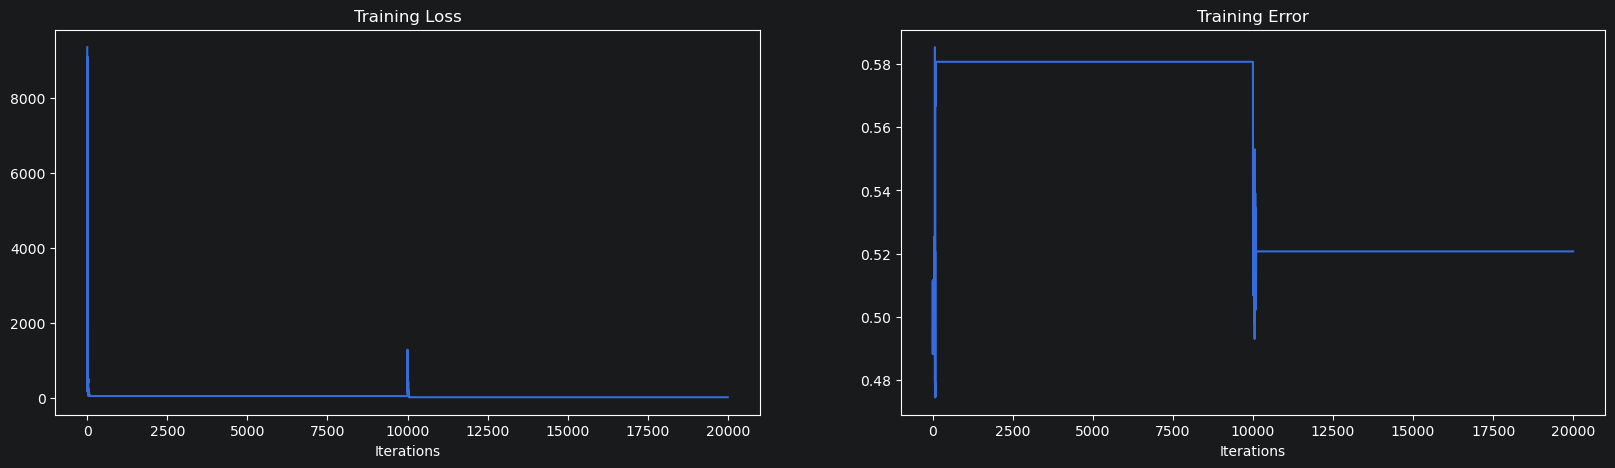

In [98]:
# Visualize in a diagram how the Loss and the training error change in the course of iteration.
# svm is called twice so this call needs to move or a blip is created in training loss because it continues to append
iterations = range(len(training_errors))

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].set_xlabel("Iterations")
axes[0].set_title("Training Loss")
axes[0].plot(iterations, losses)

axes[1].set_xlabel("Iterations")
axes[1].set_title("Training Error")
axes[1].plot(iterations, training_errors)
plt.show()